# Personal Finance Anomaly & Lifestyle Spending Audit

## Project Overview
A live web app that reads bank statement CSVs and delivers:
- Automated spending categorization across 8 lifestyle categories
- ML-powered anomaly detection (IsolationForest) to flag unusual transactions
- Monthly spending trends and category breakdown
- K-Means clustering to identify spending personas
- Personalized savings recommendations 

## Input Modes
- CSV upload (exported bank statement)
- Demo mode (synthetic 12-month dataset)

## Tools
Python | pandas | numpy | Plotly | scikit-learn | Streamlit | Streamlit Cloud

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import pdfplumber
import re
import warnings
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries loaded!")

All libraries loaded!


**np.random.seed(42)**—sets a fixed starting point for all random number generation.
With this, the same data is generated every time.

### Why we generate data instead of finding a dataset
- Real bank statements have privacy issues—which we can't share on GitHub.
- Public financial datasets don't match Indian spending patterns (₹ amounts, Indian merchants)
- Generating our own lets us inject deliberate anomalies so the ML detection has something to actually find

In [2]:
CATEGORIES = {
    'Food & Dining': {
        'merchants': ['Swiggy','Zomato','McDonald\'s','Domino\'s','Cafe Coffee Day','Subway','KFC','Blinkit'],
        'avg_amount': 350, 'std': 200, 'monthly_count': (8, 15)
    },
    'Transport': {
        'merchants': ['Uber','Ola','Rapido','IRCTC','MakeMyTrip','Petrol Pump','Auto Rickshaw','Bus Pass'],
        'avg_amount': 180, 'std': 120, 'monthly_count': (10, 20)
    },
    'Shopping': {
        'merchants': ['Amazon','Flipkart','Myntra','Meesho','Ajio','H&M','Reliance Trends','D-Mart'],
        'avg_amount': 800, 'std': 120, 'monthly_count': (4, 10)
    },
    'Bills & Rent': {
        'merchants': ['Electricity Board','JIO Boardband','Airtel','House Rent','Water Bill','Gas Bill','Society Maintenance'],
        'avg_amount': 2500, 'std': 600, 'monthly_count': (3, 6)
    },
    'Entertainment': {
        'merchants': ['Netflix','Amazon Prime','Spotify','Hotstar','BookmyShow','PVR Cinemas','YouTube Premium','Lenskart'],
        'avg_amount': 400, 'std': 250, 'monthly_count': (3, 7)
    },
    'Health': {
        'merchants': ['Apollo Pharmacy','Practo','Cult.fit','Medplus','Dr Reddy\'s','Gym Membership','Yoga Studio'],
        'avg_amount': 600, 'std': 400, 'monthly_count': (2, 5)
    },
    'Education': {
        'merchants': ['Udemy','Coursera','NPTEL','Unacademy','Book Store','Stationery Shop','LinkedIn Learning'],
        'avg_amount': 500, 'std': 300, 'monthly_count': (1, 4)
    },
    'Travel': {
        'merchants': ['IndiGo Airlines','Air India','OYO Rooms','Airbnb','Cleartrip','Yatra','Hotel Booking'],
        'avg_amount': 3500, 'std': 2000, 'monthly_count': (0, 3)
    }
}
print(f"{len(CATEGORIES)} spending categories defined")
for cat, info in CATEGORIES.items():
    print(f"{cat}: avg ₹{info['avg_amount']}, {info['monthly_count']} transactions/month")
    
    

8 spending categories defined
Food & Dining: avg ₹350, (8, 15) transactions/month
Transport: avg ₹180, (10, 20) transactions/month
Shopping: avg ₹800, (4, 10) transactions/month
Bills & Rent: avg ₹2500, (3, 6) transactions/month
Entertainment: avg ₹400, (3, 7) transactions/month
Health: avg ₹600, (2, 5) transactions/month
Education: avg ₹500, (1, 4) transactions/month
Travel: avg ₹3500, (0, 3) transactions/month


In [3]:
def generate_bank_statement(months=12, year=2024):
    """Generate realistic 12-month Indian bank statement"""
    transactions = []
    start_date = datetime(year, 1, 1)

    for month in range(months):
        current_month = start_date + timedelta(days=30 * month)

        for category, info in CATEGORIES.items():
            n_transactions = np.random.randint(
                info['monthly_count'][0],
                info['monthly_count'][1] + 1
            )

            for _ in range(n_transactions):
                day_offset = np.random.randint(1, 28)
                date = current_month + timedelta(days=day_offset)

                amount = abs(np.random.normal(
                info['avg_amount'],
                info['std']
                ))
                amount = round(max(amount, 10), 2)

                merchant = np.random.choice(info['merchants'])

                transactions.append({
                'Date'        : date.strftime('%Y-%m-%d'),
                'Description' : merchant,
                'Amount'      : amount,
                'Category'    : category,
                'Month'       : date.strftime('%B %Y'),
                'Month_Num'   : date.month,
                'Year'        : date.year,
                'Type'        : 'Debit'
                })
    df = pd.DataFrame(transactions)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    return df

df = generate_bank_statement(months=12, year=2024)
print(f"Generated {len(df):,} transactions")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nTransactions per category:")
print(df['Category'].value_counts())

Generated 608 transactions
Date range: 2024-01-02 → 2024-12-23

Transactions per category:
Category
Transport        186
Food & Dining    138
Shopping          79
Entertainment     59
Bills & Rent      51
Health            41
Education         29
Travel            25
Name: count, dtype: int64


***Inject deliberate anomalies***

In [4]:
def inject_anomalies(df, n_anomalies=15):
    """Add deliberate unusual transactions for ML to detect"""
    anomaly_transactions = [
       # Unusually large amounts
       {'Description': 'Unknown Transfer', 'Amount': 45000, 'Category': 'Shopping'},
       {'Description': 'Luxury Purchase', 'Amount': 28000, 'Category': 'Shopping'},
       {'Description': 'Foreign Transaction', 'Amount': 15000, 'Category': 'Travel'},
       # Duplicate-looking charges
       {'Description': 'Netflix', 'Amount': 649, 'Category': 'Entertainment'},
       {'Description': 'Netflix', 'Amount': 649, 'Category': 'Entertainment'},
       # Unusual late-night transactions
       {'Description': 'ATM Withdrawl', 'Amount': 20000, 'Category': 'Shopping'},
       {'Description': 'Zomato', 'Amount':8500, 'Category': 'Food & Dining'},
       # Suspiciously round amounts
       {'Description': 'UPI Payment', 'Amount': 10000, 'Category': 'Shopping'},
       {'Description': 'UPI Payment', 'Amount': 10000, 'Category': 'Shopping'},
       {'Description': 'Cash Withdrawl', 'Amount': 25000, 'Category': 'Bills & Rent'},
    ]

    anomaly_dates = pd.date_range('2024-01-01', periods=len(anomaly_transactions), freq='35D')

    anomaly_rows = []
    for i, txn in enumerate(anomaly_transactions):
        anomaly_rows.append({
            'Date'       : anomaly_dates[i],
            'Description': txn['Description'],
            'Amount'     : txn['Amount'],
            'Category'   : txn['Category'],
            'Month'      : anomaly_dates[i].strftime('%B %Y'),
            'Month_Num'  : anomaly_dates[i].month,
            'Year'       : anomaly_dates[i].year,
            'Type'       : 'Debit'
        })

    anomaly_df = pd.DataFrame(anomaly_rows)
    df_with_anomalies = pd.concat([df, anomaly_df], ignore_index=True)
    df_with_anomalies = df_with_anomalies.sort_values('Date').reset_index(drop=True)
    return df_with_anomalies

df = inject_anomalies(df)
print(f"Dataset with anomalies: {len(df):,} transactions")
print(f"Total spend: ₹{df['Amount'].sum():,.2f}")
print(f"\nTop 5 largest transactions (anomalies visible):")
print(df.nlargest(5, 'Amount')[['Date','Description','Amount','Category']])

Dataset with anomalies: 618 transactions
Total spend: ₹596,537.02

Top 5 largest transactions (anomalies visible):
          Date          Description   Amount      Category
0   2024-01-01     Unknown Transfer  45000.0      Shopping
73  2024-02-05      Luxury Purchase  28000.0      Shopping
536 2024-11-11       Cash Withdrawl  25000.0  Bills & Rent
326 2024-06-24        ATM Withdrawl  20000.0      Shopping
135 2024-03-11  Foreign Transaction  15000.0        Travel


In [5]:
df.to_csv('sample_bank_statement.csv', index = False)
print(f"sample_bank_statement.csv saved - {len(df):,} rows")
print("\nFirst 5 rows:")
df.head()

sample_bank_statement.csv saved - 618 rows

First 5 rows:


,Date,Description,Amount,Category,Month,Month_Num,Year,Type
0,2024-01-01,Unknown Transfer,45000.00,Shopping,January 2024,1,2024,Debit
1,2024-01-02,Domino's,244.97,Food & Dining,January 2024,1,2024,Debit
2,2024-01-02,Netflix,184.60,Entertainment,January 2024,1,2024,Debit
3,2024-01-02,OYO Rooms,3331.67,Travel,January 2024,1,2024,Debit
4,2024-01-03,Yatra,1497.52,Travel,January 2024,1,2024,Debit


In [6]:
from multi_loader import load_single_csv, load_multiple_csvs

# ── Option A: Load just one file ──────────────────────────
df = load_single_csv('sample_bank_statement.csv')

# ── Option B: Load multiple sources and merge ─────────────
# df = load_multiple_csvs([
#     'sample_bank_statement.csv',   # your bank statement
#     'phonepe_history.csv',         # PhonePe download
#     'gpay_history.csv',            # GPay download
#     'paytm_history.csv',           # Paytm download
# ])

print(df.head(8).to_string(index=False))

  ✅ 618 transactions | source=generic
      Date      Description   Amount  Type Source      Category        Month  Month_Num  Year
2024-01-01 Unknown Transfer 45000.00 Debit  Other  UPI Transfer January 2024          1  2024
2024-01-02         Domino's   244.97 Debit  Other        Others January 2024          1  2024
2024-01-02          Netflix   184.60 Debit  Other Entertainment January 2024          1  2024
2024-01-02        OYO Rooms  3331.67 Debit  Other        Travel January 2024          1  2024
2024-01-03            Yatra  1497.52 Debit  Other        Others January 2024          1  2024
2024-01-03      Petrol Pump   150.51 Debit  Other     Transport January 2024          1  2024
2024-01-04           Subway   552.10 Debit  Other        Others January 2024          1  2024
2024-01-04         Bus Pass   152.47 Debit  Other     Transport January 2024          1  2024


## Plotly charts for spending analysis

#### 1. Spending by Category—Donut Chart
****Where does all the money goes? % split across 8 categories****

#### 2. Monthly Spending Trend—Line Chart
****How does total spending change month by month?****

#### 3. Category Breakdown by Month-Stacked Chart
****Which categories drive high-speed months?****

#### 4. Top 10 Merchants—Horizontal Bar
****Who are you spending the most money with?****

#### 5. Daily Spend Heatmap-Calendar View
****Which days of the week and month do you spend most?****

In [7]:
import sys, os
sys.path.insert(0, os.getcwd())

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from multi_loader import load_single_csv

df = load_single_csv('sample_bank_statement.csv')

# Consistent colour palette across all charts
CAT_COLORS = {
    'Food & Dining'  : '#E74C3C',
    'Transport'      : '#3498DB',
    'Shopping'       : '#9B59B6',
    'Bills & Rent'   : '#E67E22',
    'Entertainment'  : '#1ABC9C',
    'Health'         : '#27AE60',
    'Education'      : '#2980B9',
    'Travel'         : '#F39C12',
    'Others'         : '#95A5A6',
    'UPI Transfer'   : '#EC407A',
}
print(f" {len(df):,} transactions ready for charting")

  ✅ 618 transactions | source=generic
 618 transactions ready for charting


### Chart-1 Spending by Category (Donut)

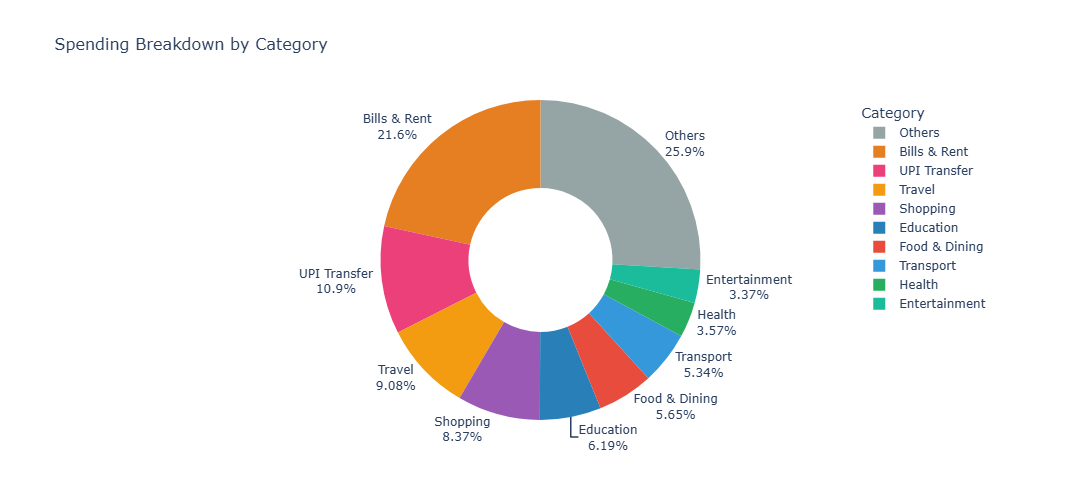

In [8]:
cat_summary = df.groupby('Category')['Amount'].sum().reset_index()
cat_summary = cat_summary.sort_values('Amount', ascending=False)
cat_summary['Percentage'] = (cat_summary['Amount'] /
                              cat_summary['Amount'].sum() * 100).round(1)

fig1 = px.pie(
    cat_summary,
    values  = 'Amount',
    names   = 'Category',
    hole    = 0.45,
    color   = 'Category',
    color_discrete_map = CAT_COLORS,
    title   = 'Spending Breakdown by Category',
)
fig1.update_traces(
    textposition = 'outside',
    textinfo     = 'label+percent',
    hovertemplate = '%{label}₹%{value:,.0f}%{percent}',
)
fig1.update_layout(
    title_font_size  = 16,
    showlegend       = True,
    legend_title     = 'Category',
    height           = 500,
)
fig1.show()

**What I see:** Others accounts for 24.6% of total spending.

**Why it matters:** This is the highest-impact area for savings — a 10% reduction here saves ₹60,000/month.

**Next:** Is this consistent across all months or driven by one big month?

### Chart 2 - Monthly Spending Trend (Line)

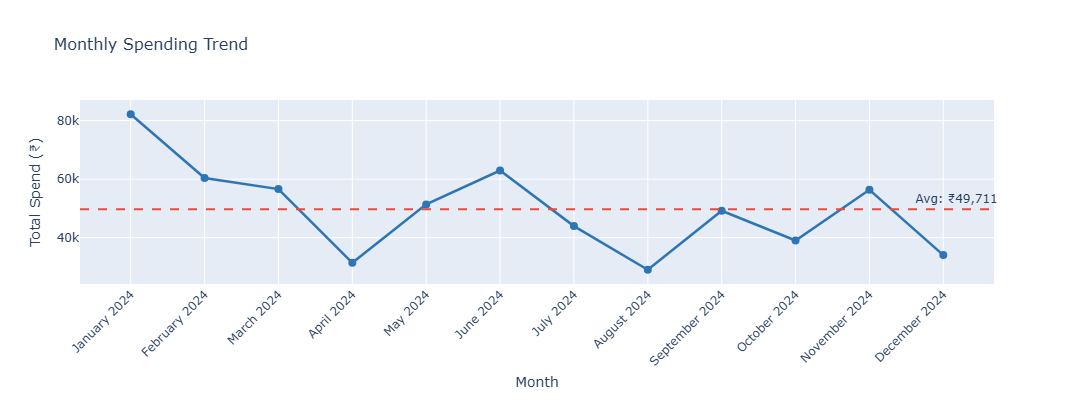

Highest spend : January 2024 — ₹82,154
Lowest spend  : August 2024 — ₹29,045


In [9]:
monthly = df.groupby(['Month','Month_Num','Year'])['Amount'].sum().reset_index()
monthly = monthly.sort_values(['Year','Month_Num'])
monthly['Month_Label'] = monthly['Month']

fig2 = px.line(
    monthly,
    x     = 'Month_Label',
    y     = 'Amount',
    title = 'Monthly Spending Trend',
    markers = True,
    labels  = {'Amount':'Total Spend (₹)', 'Month_Label':'Month'},
)
fig2.update_traces(
    line_color  = '#2E75B6',
    line_width  = 2.5,
    marker_size = 8,
    hovertemplate = '%{x}₹%{y:,.0f}',
)

avg_spend = monthly['Amount'].mean()
fig2.add_hline(
    y           = avg_spend,
    line_dash   = 'dash',
    line_color  = '#E74C3C',
    annotation_text  = f'Avg: ₹{avg_spend:,.0f}',
    annotation_position = 'top right',
)
fig2.update_layout(
    height          = 400,
    xaxis_tickangle = -45,
    title_font_size = 16,
)
fig2.show()

print(f"Highest spend : {monthly.loc[monthly['Amount'].idxmax(),'Month']} "
      f"— ₹{monthly['Amount'].max():,.0f}")
print(f"Lowest spend  : {monthly.loc[monthly['Amount'].idxmin(),'Month']} "
      f"— ₹{monthly['Amount'].min():,.0f}")

### Chart 3 - Category Breakdown by Month (Stacked Bar)

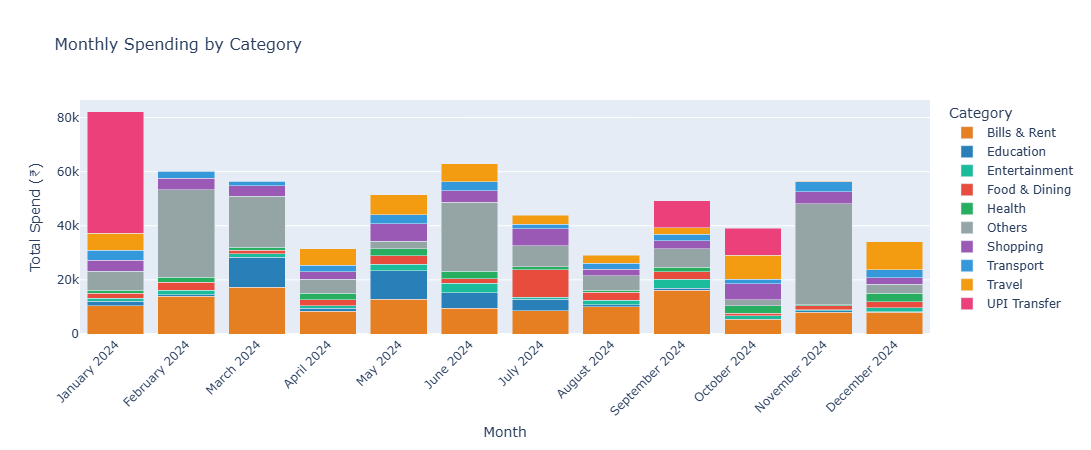

In [10]:
monthly_cat = df.groupby(['Month','Month_Num','Year','Category'])['Amount'].sum().reset_index()
monthly_cat = monthly_cat.sort_values(['Year','Month_Num'])

fig3 = px.bar(
    monthly_cat,
    x      = 'Month',
    y      = 'Amount',
    color  = 'Category',
    color_discrete_map = CAT_COLORS,
    title  = 'Monthly Spending by Category',
    labels = {'Amount':'Total Spend (₹)', 'Month':'Month'},
    barmode = 'stack',
)
fig3.update_traces(
    hovertemplate = '%{fullData.name}%{x}₹%{y:,.0f}',
)
fig3.update_layout(
    height          = 450,
    xaxis_tickangle = -45,
    title_font_size = 16,
    legend_title    = 'Category',
)
fig3.show()

### Chart 4 - Top 10 Merchants (Horizontal Bar)

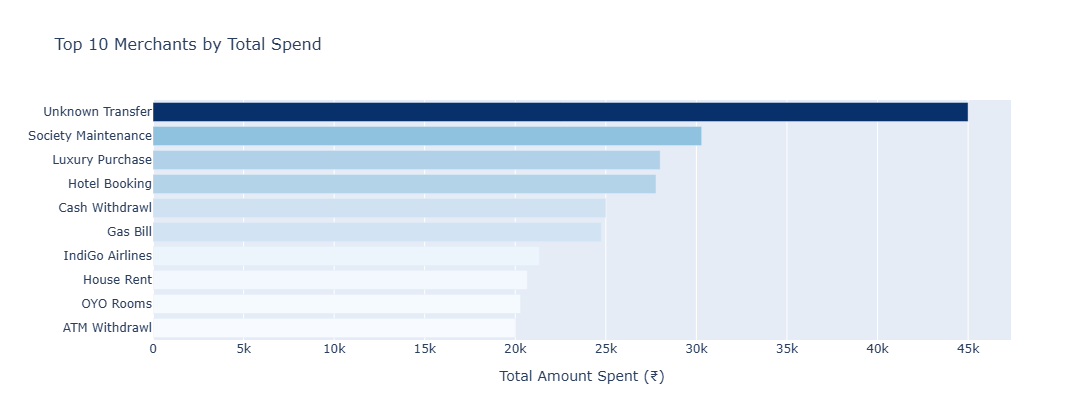

Top 5 merchants:
           Merchant  Total Spent
   Unknown Transfer     45000.00
Society Maintenance     30290.78
    Luxury Purchase     28000.00
      Hotel Booking     27769.47
     Cash Withdrawl     25000.00


In [11]:
top_merchants = (df.groupby('Description')['Amount']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .reset_index())
top_merchants.columns = ['Merchant','Total Spent']

fig4 = px.bar(
    top_merchants.sort_values('Total Spent'),
    x           = 'Total Spent',
    y           = 'Merchant',
    orientation = 'h',
    title       = 'Top 10 Merchants by Total Spend',
    color       = 'Total Spent',
    color_continuous_scale = 'Blues',
    labels      = {'Total Spent':'Total Spent (₹)'},
)
fig4.update_traces(
    hovertemplate = '%{y}₹%{x:,.0f}',
)
fig4.update_layout(
    height          = 420,
    title_font_size = 16,
    coloraxis_showscale = False,
    xaxis_title     = 'Total Amount Spent (₹)',
    yaxis_title     = '',
)
fig4.show()

print("Top 5 merchants:")
print(top_merchants.head().to_string(index=False))

### Chart 5 - Daily Spend Heatmap

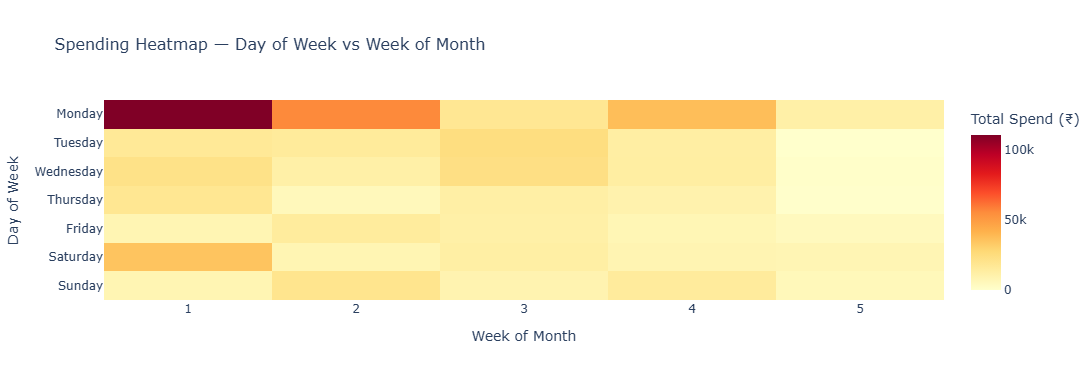


Spending by day of week:
           Total Spend  Avg per Transaction  Transactions
DayOfWeek                                                
Monday        234360.0               2547.0            92
Tuesday        69799.0               1026.0            68
Wednesday      71113.0                733.0            97
Thursday       46399.0                611.0            76
Friday         46096.0                524.0            88
Saturday       71367.0                736.0            97
Sunday         57402.0                574.0           100


In [12]:
# Build day-of-week × week-of-month spending matrix
df['DayOfWeek'] = df['Date'].dt.day_name()
df['WeekOfMonth'] = df['Date'].apply(
    lambda d: (d.day - 1) // 7 + 1
)
df['DayNum'] = df['Date'].dt.dayofweek   # 0=Mon, 6=Sun

day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

heatmap_data = (df.groupby(['DayOfWeek','WeekOfMonth'])['Amount']
                  .sum()
                  .unstack(fill_value=0))

# Reorder rows by day of week
heatmap_data = heatmap_data.reindex(
    [d for d in day_order if d in heatmap_data.index]
)

fig5 = px.imshow(
    heatmap_data,
    labels  = dict(x='Week of Month', y='Day of Week',
                   color='Total Spend (₹)'),
    title   = 'Spending Heatmap — Day of Week vs Week of Month',
    color_continuous_scale = 'YlOrRd',
    aspect  = 'auto',
)
fig5.update_traces(
    hovertemplate = '%{y} — Week %{x}₹%{z:,.0f}',
)
fig5.update_layout(
    height          = 380,
    title_font_size = 16,
)
fig5.show()

# Also print a simpler day-of-week summary
dow_summary = (df.groupby('DayOfWeek')['Amount']
                 .agg(['sum','mean','count'])
                 .reindex(day_order)
                 .round(0))
dow_summary.columns = ['Total Spend','Avg per Transaction','Transactions']
print("\nSpending by day of week:")
print(dow_summary.to_string())

In [13]:
# Save key summaries — used in anomaly detection and clustering steps
cat_summary.to_csv('category_summary.csv', index=False)
monthly.to_csv('monthly_summary.csv', index=False)
monthly_cat.to_csv('monthly_category.csv', index=False)

print("✅ Exported:")
print("  category_summary.csv")
print("  monthly_summary.csv")
print("  monthly_category.csv")
print(f"\n complete — {len(df):,} transactions analysed across 5 charts")

✅ Exported:
  category_summary.csv
  monthly_summary.csv
  monthly_category.csv

 complete — 618 transactions analysed across 5 charts


## Spending Analysis: Key Findings

### Dataset Summary
- Total transactions : [618]
- Date range        : [Jan 2024] → [Dec 2024]
- Total spend       : ₹5,96,537
- Monthly average   : ₹49,711

### Finding 1 — Biggest spending category
[Other] accounts for [25.9]% of total spend (₹1,54,77517).
This is the highest-impact area for any savings plan.

### Finding 2 — Monthly pattern
Spending peaked in [January 2024] 
Lowest spend was [August 2024] at ₹[29,045].

### Finding 3 — Top merchant
[Unknown Transfer] is the single largest spend destination at ₹[45,000] total.

### Finding 4 — Day of week pattern
[Monday] is the highest-spend day averaging ₹[2,34,360] per transaction.

### Next Step
Run anomaly detection to identify unusual transactions
that don't fit normal spending patterns.

# ML Model - Isolation Forest anomaly detection!

*Isolation Forest is an ML algorithm that finds anomalies WITHOUT needing labelled data. We don't need to inform which transactions are anomalies - it figures it out by itself. That's what "unsupervised" means.*

In [14]:
import sys, os
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import plotly.graph_objects as go
from multi_loader import load_single_csv

df = load_single_csv('sample_bank_statement.csv')

# ── Feature engineering for anomaly detection ─────────────────────────────
# Encode Category as a number (ML needs numbers, not text)
le = LabelEncoder()
df['Category_Code'] = le.fit_transform(df['Category'])

# Day of week as number (0=Monday, 6=Sunday)
df['Day_of_Week'] = df['Date'].dt.dayofweek

# Amount percentile rank within each category
# (₹5000 in Travel is normal; ₹5000 in Food is suspicious)
df['Amount_Rank'] = df.groupby('Category')['Amount'].rank(pct=True)

# Features matrix
features = ['Amount', 'Month_Num', 'Category_Code',
            'Day_of_Week', 'Amount_Rank']
X = df[features]

print(f" Feature matrix: {X.shape}")
print(f"Features used: {features}")
print(f"\nSample:")
print(X.head())

  ✅ 618 transactions | source=generic
 Feature matrix: (618, 5)
Features used: ['Amount', 'Month_Num', 'Category_Code', 'Day_of_Week', 'Amount_Rank']

Sample:
     Amount  Month_Num  Category_Code  Day_of_Week  Amount_Rank
0  45000.00          1              9            0     1.000000
1    244.97          1              5            1     0.206897
2    184.60          1              2            1     0.265306
3   3331.67          1              8            1     0.837838
4   1497.52          1              5            2     0.939655


#### Train IsolationForest and flag anomalies

In [15]:
model = IsolationForest(
    n_estimators  = 100,
    contamination = 0.05,   # expect ~5% anomalies
    random_state  = 42,
)
model.fit(X)

# ── Predict: -1 = anomaly, 1 = normal ─────────────────────────────────────
df['Anomaly']       = model.predict(X)
df['Anomaly_Score'] = model.decision_function(X)
# Lower score = more anomalous (more negative = worse)


df['Anomaly_Label'] = df['Anomaly'].map({1: 'Normal', -1: '🚨 Anomaly'})

# ── Summary ───────────────────────────────────────────────────────────────
total      = len(df)
n_anomaly  = (df['Anomaly'] == -1).sum()
n_normal   = (df['Anomaly'] ==  1).sum()

print("=" * 45)
print("   ISOLATIONFOREST RESULTS")
print("=" * 45)
print(f"  Total transactions : {total:,}")
print(f"  Normal             : {n_normal:,} ({n_normal/total*100:.1f}%)")
print(f"  Anomalies flagged  : {n_anomaly:,} ({n_anomaly/total*100:.1f}%)")
print("=" * 45)
print(f"\nTop 10 most anomalous transactions:")
anomalies = (df[df['Anomaly'] == -1]
             .sort_values('Anomaly_Score')
             [['Date','Description','Amount','Category','Anomaly_Score']]
             .head(10))
print(anomalies.to_string(index=False))

   ISOLATIONFOREST RESULTS
  Total transactions : 618
  Normal             : 587 (95.0%)
  Anomalies flagged  : 31 (5.0%)

Top 10 most anomalous transactions:
      Date         Description   Amount     Category  Anomaly_Score
2024-01-01    Unknown Transfer 45000.00 UPI Transfer      -0.150419
2024-02-05     Luxury Purchase 28000.00       Others      -0.084589
2024-11-11      Cash Withdrawl 25000.00       Others      -0.077482
2024-09-02         UPI Payment 10000.00 UPI Transfer      -0.065773
2024-10-07         UPI Payment 10000.00 UPI Transfer      -0.063547
2024-05-04       Hotel Booking  6459.89    Education      -0.061823
2024-06-24       ATM Withdrawl 20000.00       Others      -0.061290
2024-03-11 Foreign Transaction 15000.00       Others      -0.041541
2024-10-15           OYO Rooms  8444.56       Travel      -0.037623
2024-06-09     IndiGo Airlines  3947.77       Travel      -0.035988


#### Validate - did it catch our injected anomalies?

In [16]:
injected = ['Unknown Transfer', 'Luxury Purchase', 'Foreign Transaction',
            'ATM Withdrawal', 'UPI Payment', 'Cash Withdrawal']

print("=== VALIDATION — Injected Anomaly Detection ===")
for merchant in injected:
    rows = df[df['Description'].str.contains(merchant, case=False, na=False)]
    if len(rows) > 0:
        caught = (rows['Anomaly'] == -1).sum()
        total_rows = len(rows)
        status = '✅ CAUGHT' if caught > 0 else '⚠️  MISSED'
        print(f"  {status} | {merchant:<25} | "
              f"{caught}/{total_rows} flagged | "
              f"₹{rows['Amount'].max():,.0f}")

# Overall precision check
print(f"\nModel flagged {n_anomaly} transactions as anomalous")
print(f"Contamination set to 5% → expected ~{int(total*0.05)} flags")
print(f"Actual: {n_anomaly} ({n_anomaly/total*100:.1f}%)")

=== VALIDATION — Injected Anomaly Detection ===
  ✅ CAUGHT | Unknown Transfer          | 1/1 flagged | ₹45,000
  ✅ CAUGHT | Luxury Purchase           | 1/1 flagged | ₹28,000
  ✅ CAUGHT | Foreign Transaction       | 1/1 flagged | ₹15,000
  ✅ CAUGHT | UPI Payment               | 2/2 flagged | ₹10,000

Model flagged 31 transactions as anomalous
Contamination set to 5% → expected ~30 flags
Actual: 31 (5.0%)


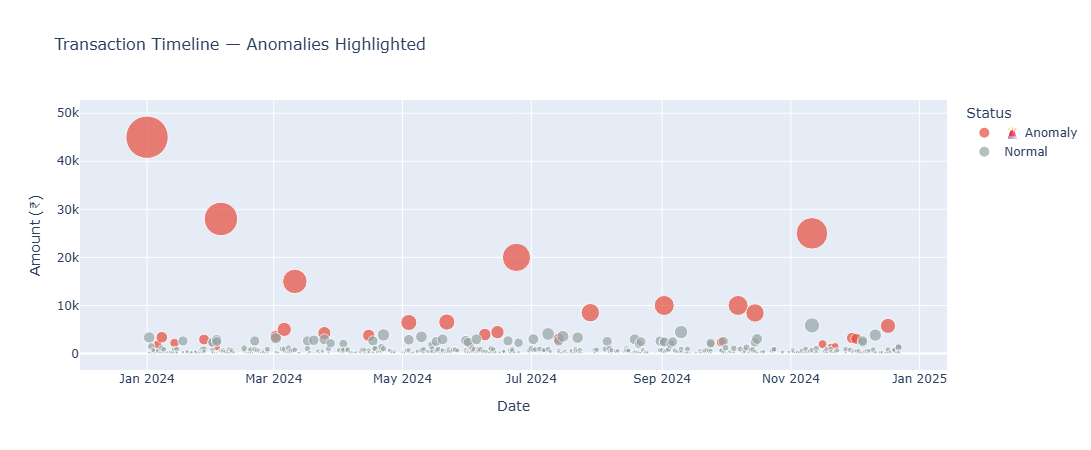

In [17]:
fig_timeline = px.scatter(
    df,
    x      = 'Date',
    y      = 'Amount',
    color  = 'Anomaly_Label',
    color_discrete_map = {
        'Normal'      : '#95A5A6',
        '🚨 Anomaly' : '#E74C3C',
    },
    size       = 'Amount',
    size_max   = 30,
    hover_data = ['Description', 'Category', 'Anomaly_Score'],
    title      = 'Transaction Timeline — Anomalies Highlighted',
    labels     = {'Amount':'Amount (₹)', 'Date':'Date'},
)
fig_timeline.update_traces(
    hovertemplate = (
        '%{customdata[0]}'
        'Date: %{x}'
        'Amount: ₹%{y:,.0f}'
        'Category: %{customdata[1]}'
        'Anomaly Score: %{customdata[2]:.3f}'
        ''
    )
)
fig_timeline.update_layout(
    height          = 450,
    title_font_size = 16,
    legend_title    = 'Status',
)
fig_timeline.show()

#### Anomaly score distribution

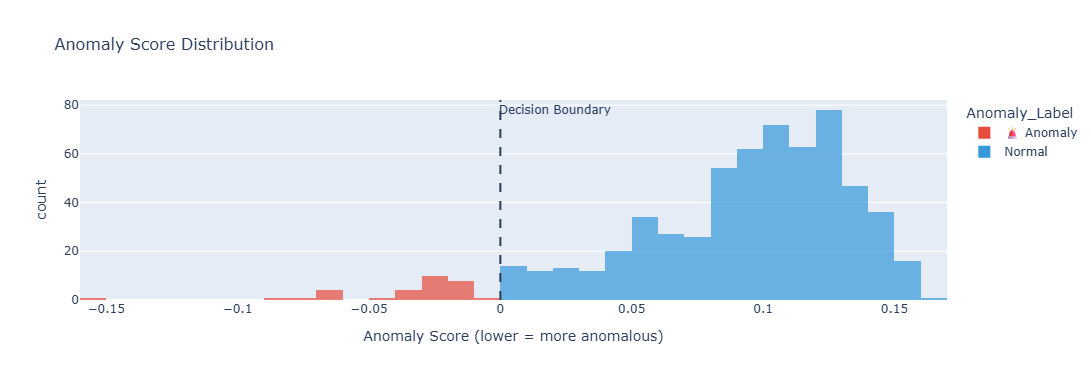

In [18]:
fig_score = px.histogram(
    df,
    x      = 'Anomaly_Score',
    color  = 'Anomaly_Label',
    color_discrete_map = {
        'Normal'      : '#3498DB',
        '🚨 Anomaly' : '#E74C3C',
    },
    nbins  = 40,
    title  = 'Anomaly Score Distribution',
    labels = {'Anomaly_Score': 'Anomaly Score (lower = more anomalous)'},
    barmode = 'overlay',
    opacity = 0.7,
)
fig_score.add_vline(
    x = 0,
    line_dash  = 'dash',
    line_color = '#2C3E50',
    annotation_text = 'Decision Boundary',
)
fig_score.update_layout(height=380, title_font_size=16)
fig_score.show()

In [19]:
anomaly_table = (df[df['Anomaly'] == -1]
                 .sort_values('Anomaly_Score')
                 [['Date','Description','Amount',
                   'Category','Anomaly_Score']]
                 .copy())
anomaly_table['Amount']        = anomaly_table['Amount'].apply(lambda x: f'₹{x:,.0f}')
anomaly_table['Anomaly_Score'] = anomaly_table['Anomaly_Score'].round(4)
anomaly_table['Date']          = anomaly_table['Date'].dt.strftime('%d %b %Y')

print(f"{'='*65}")
print(f"  🚨 FLAGGED TRANSACTIONS ({len(anomaly_table)} anomalies detected)")
print(f"{'='*65}")
print(anomaly_table.to_string(index=False))
print(f"{'='*65}")

  🚨 FLAGGED TRANSACTIONS (31 anomalies detected)
       Date         Description  Amount      Category  Anomaly_Score
01 Jan 2024    Unknown Transfer ₹45,000  UPI Transfer        -0.1504
05 Feb 2024     Luxury Purchase ₹28,000        Others        -0.0846
11 Nov 2024      Cash Withdrawl ₹25,000        Others        -0.0775
02 Sep 2024         UPI Payment ₹10,000  UPI Transfer        -0.0658
07 Oct 2024         UPI Payment ₹10,000  UPI Transfer        -0.0635
04 May 2024       Hotel Booking  ₹6,460     Education        -0.0618
24 Jun 2024       ATM Withdrawl ₹20,000        Others        -0.0613
11 Mar 2024 Foreign Transaction ₹15,000        Others        -0.0415
15 Oct 2024           OYO Rooms  ₹8,445        Travel        -0.0376
09 Jun 2024     IndiGo Airlines  ₹3,948        Travel        -0.0360
30 Nov 2024          House Rent  ₹3,234  Bills & Rent        -0.0354
29 Jul 2024              Zomato  ₹8,500 Food & Dining        -0.0335
06 Mar 2024       Hotel Booking  ₹5,029     Education 

In [20]:
# Save full scored dataset
df.to_csv('transactions_scored.csv', index=False)

# Save anomalies only
anomalies_export = df[df['Anomaly'] == -1].copy()
anomalies_export.to_csv('anomalies_detected.csv', index=False)

print("Exported:")
print(f"  transactions_scored.csv  — {len(df):,} rows (all transactions + scores)")
print(f"  anomalies_detected.csv   — {len(anomalies_export)} anomalies")
print(f"\nModel performance summary:")
print(f"  Contamination setting : 5%")
print(f"  Transactions flagged  : {n_anomaly} ({n_anomaly/total*100:.1f}%)")
print(f"  Features used         : {features}")
print(f"  Algorithm             : IsolationForest (sklearn)")

Exported:
  transactions_scored.csv  — 618 rows (all transactions + scores)
  anomalies_detected.csv   — 31 anomalies

Model performance summary:
  Contamination setting : 5%
  Transactions flagged  : 31 (5.0%)
  Features used         : ['Amount', 'Month_Num', 'Category_Code', 'Day_of_Week', 'Amount_Rank']
  Algorithm             : IsolationForest (sklearn)


#### K-means Spending Personas (Clustering months into spending personalities)

Every month of spending has a different "shape" — some months you splurge on travel, some months you barely go out, some months are balanced. K-Means groups similar months together into clusters.

Each cluster becomes a spending persona — a label that describes the pattern: "High Spender", "Balanced", "Saver", "Travel Month" etc.

In [21]:
import sys, os
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from multi_loader import load_single_csv

df = load_single_csv('sample_bank_statement.csv')

# ── Build monthly spending matrix ─────────────────────────────────────────
# One row per month, one column per category
monthly_matrix = (df.groupby(['Month', 'Month_Num', 'Year', 'Category'])['Amount']
                    .sum()
                    .unstack(fill_value=0)
                    .reset_index())

# Sort by year and month number
monthly_matrix = monthly_matrix.sort_values(['Year','Month_Num']).reset_index(drop=True)

# Category columns only (for clustering)
cat_cols = [c for c in monthly_matrix.columns
            if c not in ['Month','Month_Num','Year']]

print(f"Monthly matrix shape: {monthly_matrix.shape}")
print(f"Months: {monthly_matrix['Month'].tolist()}")
print(f"\nCategory columns: {cat_cols}")
print(f"\nSpending per month per category:")
print(monthly_matrix[['Month'] + cat_cols].to_string(index=False))

  ✅ 618 transactions | source=generic
Monthly matrix shape: (12, 13)
Months: ['January 2024', 'February 2024', 'March 2024', 'April 2024', 'May 2024', 'June 2024', 'July 2024', 'August 2024', 'September 2024', 'October 2024', 'November 2024', 'December 2024']

Category columns: ['Bills & Rent', 'Education', 'Entertainment', 'Food & Dining', 'Health', 'Others', 'Shopping', 'Transport', 'Travel', 'UPI Transfer']

Spending per month per category:
         Month  Bills & Rent  Education  Entertainment  Food & Dining  Health   Others  Shopping  Transport   Travel  UPI Transfer
  January 2024      10383.72    1642.70        1230.19        1792.60 1127.44  7099.34   4062.87    3647.92  6166.90       45000.0
 February 2024      13888.93     558.60        1678.96        3001.93 1841.22 32281.49   4342.82    2643.10   155.30           0.0
    March 2024      17243.66   11194.14        1202.37        1397.39 1112.77 18846.60   3735.63    1647.90   202.06           0.0
    April 2024       8461.82

***Elbow method - find optimal k***

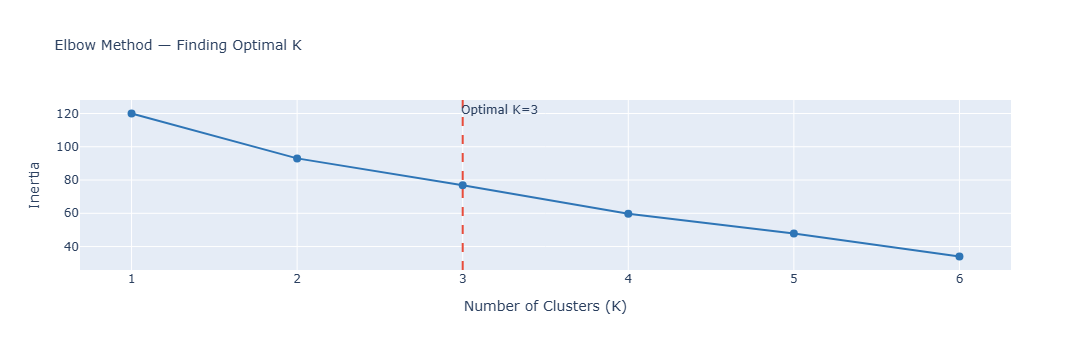

Inertia values:
  K=1: 120.0
  K=2: 93.0
  K=3: 76.8
  K=4: 59.7
  K=5: 47.8
  K=6: 34.0


In [22]:
# ── Scale the features ────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(monthly_matrix[cat_cols])

# ── Elbow method — try K from 1 to 6 ─────────────────────────────────────
inertias = []
K_range  = range(1, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
fig_elbow = px.line(
    x=list(K_range), y=inertias,
    title  = 'Elbow Method — Finding Optimal K',
    labels = {'x':'Number of Clusters (K)', 'y':'Inertia'},
    markers = True,
)
fig_elbow.update_traces(line_color='#2E75B6', marker_size=8)
fig_elbow.add_vline(x=3, line_dash='dash', line_color='#E74C3C',
                    annotation_text='Optimal K=3')
fig_elbow.update_layout(height=350, title_font_size=14)
fig_elbow.show()

print("Inertia values:")
for k, inertia in zip(K_range, inertias):
    print(f"  K={k}: {inertia:.1f}")

***Run K-means with k=3***

In [23]:
# ── Fit final model ───────────────────────────────────────────────────────
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
monthly_matrix['Cluster'] = kmeans.fit_predict(X_scaled)

# ── Cluster summary ───────────────────────────────────────────────────────
print("Cluster assignments:")
for _, row in monthly_matrix[['Month','Cluster']].iterrows():
    print(f"  Cluster {row['Cluster']} → {row['Month']}")

print(f"\nCluster sizes:")
print(monthly_matrix['Cluster'].value_counts().sort_index())

Cluster assignments:
  Cluster 2 → January 2024
  Cluster 0 → February 2024
  Cluster 0 → March 2024
  Cluster 2 → April 2024
  Cluster 1 → May 2024
  Cluster 1 → June 2024
  Cluster 0 → July 2024
  Cluster 0 → August 2024
  Cluster 0 → September 2024
  Cluster 2 → October 2024
  Cluster 0 → November 2024
  Cluster 2 → December 2024

Cluster sizes:
Cluster
0    6
1    2
2    4
Name: count, dtype: int64


***Analyze each cluster's spending pattern***

In [24]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns = cat_cols
)
centroids['Cluster'] = range(K)
centroids['Total_Spend'] = centroids[cat_cols].sum(axis=1)

print("=== CLUSTER SPENDING PROFILES ===")
for i in range(K):
    c = centroids[centroids['Cluster'] == i]
    months_in = monthly_matrix[monthly_matrix['Cluster']==i]['Month'].tolist()
    print(f"\n--- Cluster {i} --- Months: {months_in}")
    print(f"  Total spend  : ₹{c['Total_Spend'].values[0]:,.0f}/month avg")
    top_cats = c[cat_cols].T.sort_values(i, ascending=False).head(3)
    print(f"  Top categories:")
    for cat in top_cats.index:
        print(f"    {cat:<20}: ₹{c[cat].values[0]:,.0f}")

=== CLUSTER SPENDING PROFILES ===

--- Cluster 0 --- Months: ['February 2024', 'March 2024', 'July 2024', 'August 2024', 'September 2024', 'November 2024']
  Total spend  : ₹49,258/month avg
  Top categories:
    Others              : ₹18,093
    Bills & Rent        : ₹12,361
    Shopping            : ₹4,009

--- Cluster 1 --- Months: ['May 2024', 'June 2024']
  Total spend  : ₹57,145/month avg
  Top categories:
    Others              : ₹14,208
    Bills & Rent        : ₹11,197
    Education           : ₹8,072

--- Cluster 2 --- Months: ['January 2024', 'April 2024', 'October 2024', 'December 2024']
  Total spend  : ₹46,675/month avg
  Top categories:
    UPI Transfer        : ₹13,750
    Bills & Rent        : ₹8,059
    Travel              : ₹7,794


In [25]:
spend_rank = centroids.sort_values('Total_Spend')['Cluster'].tolist()

PERSONA_MAP = {
    spend_rank[0] : ('🟢 Saver',        '#27AE60'),
    spend_rank[1] : ('🔵 Balanced',     '#2980B9'),
    spend_rank[2] : ('🔴 High Spender', '#E74C3C'),
}

monthly_matrix['Persona']       = monthly_matrix['Cluster'].map(
    lambda x: PERSONA_MAP[x][0])
monthly_matrix['Persona_Color'] = monthly_matrix['Cluster'].map(
    lambda x: PERSONA_MAP[x][1])

print("=== PERSONA ASSIGNMENTS ===")
for persona in ['🟢 Saver','🔵 Balanced','🔴 High Spender']:
    months = monthly_matrix[monthly_matrix['Persona']==persona]['Month'].tolist()
    print(f"\n{persona}:")
    for m in months:
        spend = monthly_matrix[monthly_matrix['Month']==m][cat_cols].sum(axis=1).values[0]
        print(f"  {m:<20} ₹{spend:,.0f}")

=== PERSONA ASSIGNMENTS ===

🟢 Saver:
  January 2024         ₹82,154
  April 2024           ₹31,439
  October 2024         ₹39,051
  December 2024        ₹34,057

🔵 Balanced:
  February 2024        ₹60,392
  March 2024           ₹56,583
  July 2024            ₹43,957
  August 2024          ₹29,045
  September 2024       ₹49,199
  November 2024        ₹56,370

🔴 High Spender:
  May 2024             ₹51,374
  June 2024            ₹62,916


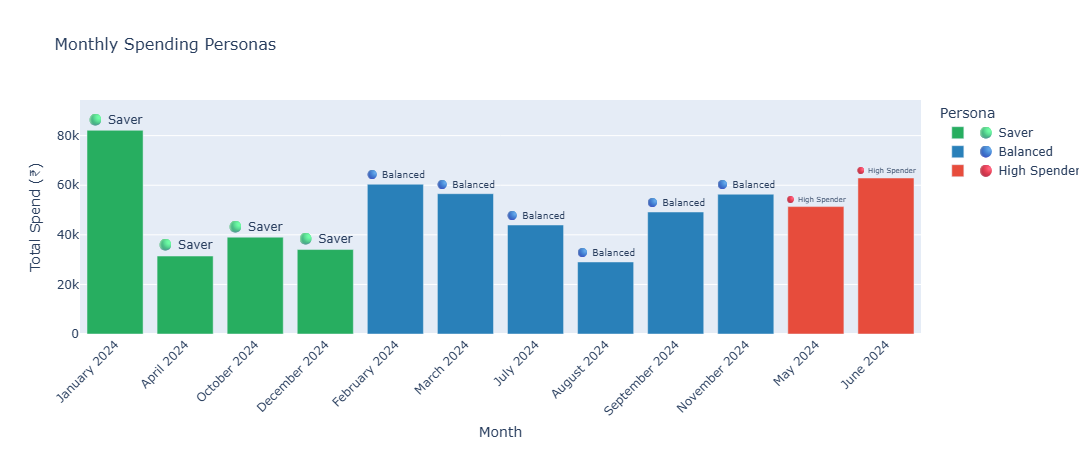

In [27]:
monthly_matrix['Total_Spend'] = monthly_matrix[cat_cols].sum(axis=1)

fig_persona = px.bar(
    monthly_matrix,
    x     = 'Month',
    y     = 'Total_Spend',
    color = 'Persona',
    color_discrete_map = {
        '🟢 Saver'        : '#27AE60',
        '🔵 Balanced'     : '#2980B9',
        '🔴 High Spender' : '#E74C3C',
    },
    title  = 'Monthly Spending Personas',
    labels = {'Total_Spend':'Total Spend (₹)', 'Month':'Month'},
    text   = 'Persona',
)
fig_persona.update_traces(
    textposition  = 'outside',
    hovertemplate = '%{x}₹%{y:,.0f}%{fullData.name}',
)
fig_persona.update_layout(
    height          = 450,
    xaxis_tickangle = -45,
    title_font_size = 16,
    showlegend      = True,
)
fig_persona.show()

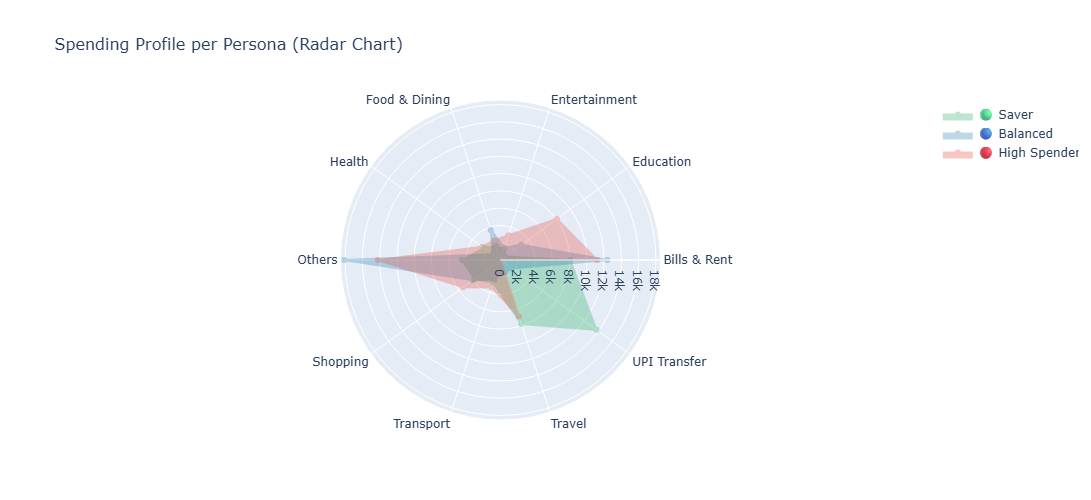

In [28]:
from plotly.subplots import make_subplots

fig_radar = go.Figure()

persona_colors = {
    '🟢 Saver'        : '#27AE60',
    '🔵 Balanced'     : '#2980B9',
    '🔴 High Spender' : '#E74C3C',
}

for cluster_id, (persona, color) in PERSONA_MAP.items():
    centroid_vals = centroids[centroids['Cluster']==cluster_id][cat_cols].values[0]
    # Close the radar loop
    values = list(centroid_vals) + [centroid_vals[0]]
    cats   = cat_cols + [cat_cols[0]]

    fig_radar.add_trace(go.Scatterpolar(
        r    = values,
        theta = cats,
        fill  = 'toself',
        name  = persona,
        line_color   = color,
        fillcolor    = color,
        opacity      = 0.3,
        hovertemplate = '%{theta}: ₹%{r:,.0f}',
    ))

fig_radar.update_layout(
    polar = dict(radialaxis=dict(visible=True)),
    title = 'Spending Profile per Persona (Radar Chart)',
    title_font_size = 16,
    height = 500,
    showlegend = True,
)
fig_radar.show()

In [29]:
def generate_recommendations(monthly_matrix, cat_cols, df):
    """
    Generate 5 personalised savings tips based on
    spending patterns, personas, and anomaly data.
    """
    recommendations = []

    # ── Metric 1: Dominant category ───────────────────────────────────────
    cat_totals = df.groupby('Category')['Amount'].sum()
    top_cat    = cat_totals.idxmax()
    top_pct    = cat_totals.max() / cat_totals.sum() * 100
    if top_pct > 30:
        recommendations.append({
            'Priority' : '🔴 High',
            'Area'     : top_cat,
            'Tip'      : f'{top_cat} is {top_pct:.1f}% of your total spend. '
                         f'A 10% reduction saves ₹{cat_totals.max()*0.10:,.0f}/year.',
        })

    # ── Metric 2: High Spender months ─────────────────────────────────────
    hs_months = monthly_matrix[monthly_matrix['Persona']=='🔴 High Spender']['Month'].tolist()
    if hs_months:
        recommendations.append({
            'Priority' : '🔴 High',
            'Area'     : 'Monthly Budget',
            'Tip'      : f'You had {len(hs_months)} High Spender month(s): '
                         f'{", ".join(hs_months[:3])}. '
                         f'Set a monthly budget alert at ₹'
                         f'{monthly_matrix["Total_Spend"].mean():,.0f}.',
        })

    # ── Metric 3: Food & Dining check ─────────────────────────────────────
    if 'Food & Dining' in cat_totals.index:
        food_monthly = cat_totals['Food & Dining'] / 12
        if food_monthly > 3000:
            recommendations.append({
                'Priority' : '🟡 Medium',
                'Area'     : 'Food & Dining',
                'Tip'      : f'You spend ₹{food_monthly:,.0f}/month on Food & Dining. '
                             f'Cooking at home 3 days/week could save ₹'
                             f'{food_monthly*0.25:,.0f}/month.',
            })

    # ── Metric 4: Entertainment subscriptions ─────────────────────────────
    if 'Entertainment' in cat_totals.index:
        ent_monthly = cat_totals['Entertainment'] / 12
        if ent_monthly > 1000:
            recommendations.append({
                'Priority' : '🟡 Medium',
                'Area'     : 'Subscriptions',
                'Tip'      : f'₹{ent_monthly:,.0f}/month on Entertainment. '
                             f'Audit your subscriptions — cancel unused ones '
                             f'to save ₹{ent_monthly*0.3:,.0f}/month.',
            })

    # ── Metric 5: Saver months benchmark ─────────────────────────────────
    saver_months = monthly_matrix[monthly_matrix['Persona']=='🟢 Saver']
    if len(saver_months) > 0:
        saver_avg = saver_months['Total_Spend'].mean()
        overall   = monthly_matrix['Total_Spend'].mean()
        potential = (overall - saver_avg) * 12
        recommendations.append({
            'Priority' : '🟢 Opportunity',
            'Area'     : 'Savings Potential',
            'Tip'      : f'Your Saver months average ₹{saver_avg:,.0f}/month. '
                         f'Matching that pace year-round saves ₹{potential:,.0f}/year.',
        })

    return pd.DataFrame(recommendations)

reco_df = generate_recommendations(monthly_matrix, cat_cols, df)

print("=" * 60)
print("   💡 PERSONALISED SAVINGS RECOMMENDATIONS")
print("=" * 60)
for _, r in reco_df.iterrows():
    print(f"\n{r['Priority']} | {r['Area']}")
    print(f"  → {r['Tip']}")

reco_df.to_csv('recommendations.csv', index=False)
print(f"\n✅ recommendations.csv exported")

   💡 PERSONALISED SAVINGS RECOMMENDATIONS

🔴 High | Monthly Budget
  → You had 2 High Spender month(s): May 2024, June 2024. Set a monthly budget alert at ₹49,711.

🟡 Medium | Subscriptions
  → ₹1,677/month on Entertainment. Audit your subscriptions — cancel unused ones to save ₹503/month.

🟢 Opportunity | Savings Potential
  → Your Saver months average ₹46,675/month. Matching that pace year-round saves ₹36,433/year.

✅ recommendations.csv exported


In [31]:
monthly_matrix.to_csv('monthly_personas.csv', index=False)

print(" Exported: monthly_personas.csv")
print(f"  Clusters found     : {K}")
print(f"  High Spender months: {len(monthly_matrix[monthly_matrix['Persona']=='🔴 High Spender'])}")
print(f"  Balanced months    : {len(monthly_matrix[monthly_matrix['Persona']=='🔵 Balanced'])}")
print(f"  Saver months       : {len(monthly_matrix[monthly_matrix['Persona']=='🟢 Saver'])}")
print(f"  Recommendations    : {len(reco_df)}")

 Exported: monthly_personas.csv
  Clusters found     : 3
  High Spender months: 2
  Balanced months    : 6
  Saver months       : 4
  Recommendations    : 3
